In [1]:
import numpy as np
import os
from glob import glob
import matplotlib.pyplot as plt
import pickle
from spectral.io import envi
from collections import OrderedDict

from isofit.core.fileio import IO
from isofit.core.forward import ForwardModel
from isofit.inversion.inverse import Inversion
from isofit.inversion.inverse_simple import invert_algebraic, invert_analytical
from isofit.configs import configs
from isofit.core.geometry import Geometry

import sys
sys.path.append('/store/carroll/repos/neon-isofit/')
from utilities import viz_rfl_subset

%matplotlib widget

In [2]:
base_dir =  '/store/carroll/col/data/2018/test_flightlines/'
raw_dir = '/store/carroll/col/data/2018/test_flightlines/subsets/'
out_figs = '/store/carroll/col/figs/'

surface_path = '/store/carroll/col/data/2018/test_roi/surface_20240103_avirii_20250730.mat'
lut_config_path = '/store/carroll/col/data/2018/test_roi/lut_config_20250922.json'
channelized_uncertainty_path = '/store/carroll/col/data/avirisng_systematic_error_neon.txt'
rcc_path = '/store/carroll/col/data/2018/test_rccs/rcc_frankenstein_20250908.txt'

version = '6c_20250923'
flight_id = 'NIS01_20180612_155442'
working_dir = os.path.join(base_dir, f'{flight_id}_{version}')

In [3]:
home = '/store/carroll/col/data/2018/'

fp = glob(os.path.join(working_dir, 'output', '*_rfl.hdr'))[0]
wl = np.array([float(x) for x in envi.read_envi_header(fp)['wavelength']])
def closest_wl(mv):
    return np.argmin(np.abs(wl-mv))
wl_nan = wl.copy()
wl_nan[closest_wl(1360):closest_wl(1410)] = np.nan
wl_nan[closest_wl(1800):closest_wl(1970)] = np.nan

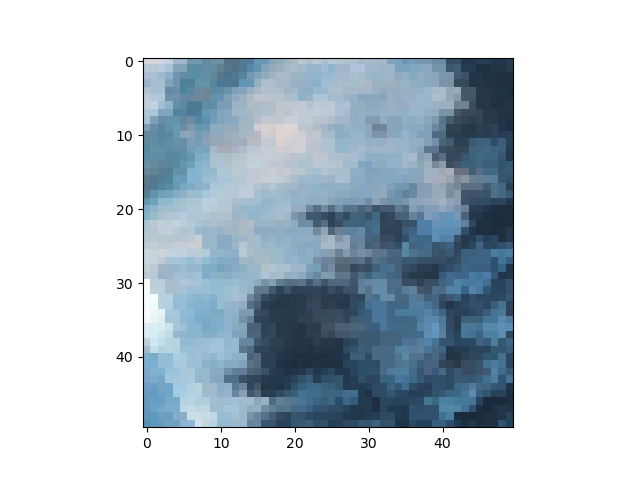

In [4]:
# just look at the rdn? Why is the bottom right so weird

rgb = envi.open(os.path.join(raw_dir, 'NIS01_20180612_155442_rdn.hdr')).open_memmap()[:,:,[60,40,30]]

fig = plt.figure()
plt.imshow(rgb / np.nanmax(rgb, axis=(0, 1)))
plt.show()

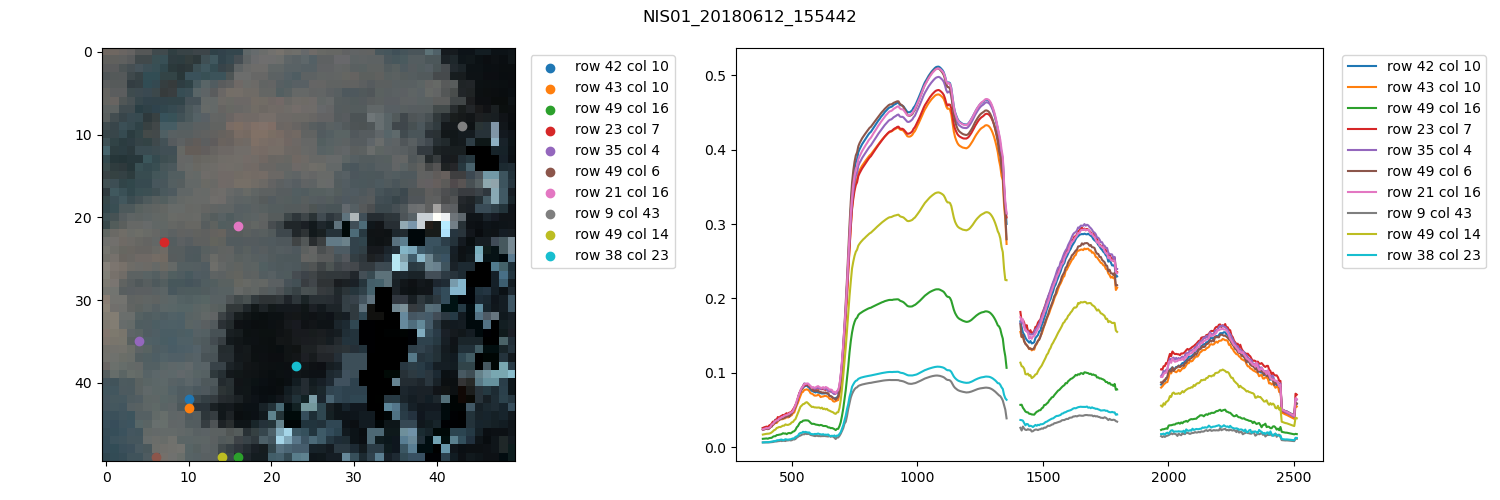

In [19]:
# this was the original run, without any of my updates (rccs, channelized uncertainty, etc)
# first viz rfl output and random pts

size = 50
row1 = 0; col1 = 0

viz_rfl_subset(flight=flight_id, working_dir=working_dir, row1=row1, col1=col1, size=size, n_sample=10, wl=wl_nan)

plt.savefig(os.path.join(out_figs, f'rfl_{flight_id}_{version}_row{row1}_col{col1}.png'), dpi=300)

In [19]:
# # load inputs
# row=25; col=25
# rdn = envi.open(os.path.join(raw_dir, f'{flight_id}_rdn.hdr')).open_memmap()[row, col, :]
# obs = envi.open(os.path.join(raw_dir, f'{flight_id}_obs.hdr')).open_memmap()[row, col, :]
# loc = envi.open(os.path.join(raw_dir, f'{flight_id}_loc.hdr')).open_memmap()[row, col, :]

# # load config
# fp_config = os.path.join(working_dir, 'config', f'{flight_id}_isofit.json')
# config = configs.create_new_config(fp_config)

# # set up forward model, io, inversion according to config
# fm = ForwardModel(config)
# io = IO(config, fm)
# inv = Inversion(config, fm)

# geom = Geometry(obs=obs, loc=loc)
# geom.sky_view_factor = 1

# meas = rdn.copy()
# # meas = meas*rcc

# # retrieve rfl
# states=inv.invert(meas, geom)
# # xa_surface = fm.surface.xa(states[0,...][fm.idx_surface].copy(), geom) # get surface prior mean
# # x_surface, x_RT, x_instrument = fm.unpack(states[-1,:])
# # x_alg, coeffs = invert_algebraic(fm.surface, fm.RT, fm.instrument, x_surface, x_RT, x_instrument, meas, geom)
# # rfl_est = fm.surface.fit_params(x_alg, geom)
# # x0 = np.concatenate([rfl_est, x_RT, x_instrument])
# # states, unc, EXIT_CODE = invert_analytical(inv.fm, inv.winidx, meas, geom, np.copy(x0), states[-1,:], num_iter = 1, hash_table = OrderedDict(), hash_size = 500)
# # out_rfl_est = states[-1, fm.idx_surf_rfl]

/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer.py:380: RuntimeWarning: divide by zero encountered in divide
  L_dir_dir = L_coupled[0] / coszen * cos_i
/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer.py:380: RuntimeWarning: invalid value encountered in divide
  L_dir_dir = L_coupled[0] / coszen * cos_i
/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer.py:382: RuntimeWarning: divide by zero encountered in divide
  L_dir_dif = L_coupled[2] / coszen * cos_i
/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer.py:382: RuntimeWarning: invalid value encountered in divide
  L_dir_dif = L_coupled[2] / coszen * cos_i
/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/inversion/inverse_simple.py:119: Runtime

ValueError: array must not contain infs or NaNs

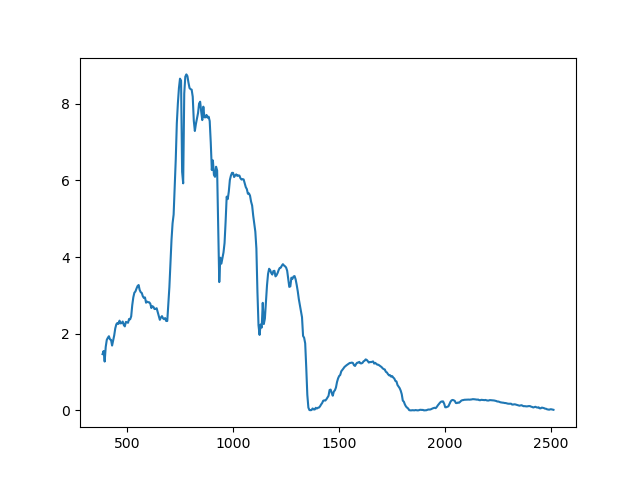

In [18]:
fig = plt.figure()
plt.plot(wl, meas)
plt.show()

In [ ]:
rdn = bright_dark_px[flight_id][k]['rdn']
obs = bright_dark_px[flight_id][k]['obs']
loc = bright_dark_px[flight_id][k]['loc']

# load config as-is
fp_config = os.path.join(working_dir, 'config', f'{flight_id}_isofit.json')
config = configs.create_new_config(fp_config)

# set up forward model, io, inversion according to config
fm = ForwardModel(config)
io = IO(config, fm)
inv = Inversion(config, fm)

# load the isofit geometry representation of the single pixel
geom = Geometry(obs=obs, loc=loc)
geom.sky_view_factor = 1 # updated isofit dev 8/20 and now this is necessary? Not sure why skyview factor is no longer automatically populating to 1 when none provided

# adjust rdn
meas = rdn.copy()
meas = meas*rcc

# retrieve rfl
states=inv.invert(meas, geom)
xa_surface = fm.surface.xa(states[0,...][fm.idx_surface].copy(), geom) # get surface prior mean
x_surface, x_RT, x_instrument = fm.unpack(states[-1,:])
x_alg, coeffs = invert_algebraic(fm.surface, fm.RT, fm.instrument, x_surface, x_RT, x_instrument, meas, geom)
rfl_est = fm.surface.fit_params(x_alg, geom)
x0 = np.concatenate([rfl_est, x_RT, x_instrument])
states, unc, EXIT_CODE = invert_analytical(inv.fm, inv.winidx, meas, geom, np.copy(x0), states[-1,:], num_iter = 1, hash_table = OrderedDict(), hash_size = 500)
out_rfl_est = states[-1, fm.idx_surf_rfl]